In [1]:
# Reload everything after numpy fix
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '/root/.local/lib/python3.12/site-packages')

# Set random seed
np.random.seed(42)

print(f"NumPy version: {np.__version__}")

# Reload cleaned data
df_prote_filtered = pd.read_csv('step1_cleaned_proteomics.csv', index_col=0)
sample_meta_filtered = pd.read_csv('step1_sample_metadata.csv')

print(f"Data shape: {df_prote_filtered.shape}")


NumPy version: 1.26.4


Data shape: (8146, 1209)


In [2]:
# Log2 transformation and imputation
print("=== Log2 Transformation and Imputation ===")

df_log2 = np.log2(df_prote_filtered.replace(0, np.nan))

# Impute with shifted minimum per protein
min_per_protein = df_log2.min(axis=1)
df_imputed = df_log2.copy()
for protein in df_imputed.index:
    mask = df_imputed.loc[protein].isna()
    if mask.sum() > 0:
        impute_val = min_per_protein[protein] - 1
        df_imputed.loc[protein, mask] = impute_val

print(f"Missing values after imputation: {df_imputed.isna().sum().sum()}")

# Set up batch info
sample_order = df_imputed.columns.tolist()
sample_meta_sorted = sample_meta_filtered.set_index('sample').loc[sample_order].reset_index()
batch_labels = sample_meta_sorted['batch'].values

print(f"Samples: {len(sample_order)}")
print(f"Batches: {np.unique(batch_labels)}")


=== Log2 Transformation and Imputation ===


Missing values after imputation: 0
Samples: 1209
Batches: ['Blue1' 'Blue2' 'Blue3' 'Blue4' 'Blue5' 'Blue6' 'Red1' 'Red2' 'Red3'
 'Red4' 'Red5' 'Red6' 'Redmix']


In [3]:
# Import inmoose for ComBat
from inmoose.pycombat import pycombat_norm

print("=== ComBat Batch Correction ===")

# Run ComBat - inmoose pycombat_norm expects:
# - data: DataFrame with genes/proteins as rows, samples as columns
# - batch: Series with sample names as index and batch labels as values
batch_series = pd.Series(batch_labels, index=df_imputed.columns)

df_corrected = pycombat_norm(df_imputed, batch_series)

print(f"\nBatch correction complete!")
print(f"Data shape: {df_corrected.shape}")
print(f"Data range after correction:")
print(f"  Min: {df_corrected.min().min():.2f}")
print(f"  Max: {df_corrected.max().max():.2f}")
print(f"  Mean: {df_corrected.values.mean():.2f}")


=== ComBat Batch Correction ===



Batch correction complete!
Data shape: (8146, 1209)
Data range after correction:
  Min: 3.26
  Max: 36.37
  Mean: 21.29


In [4]:
# Save batch-corrected data
df_corrected.to_csv('step2_batch_corrected_proteomics.csv')
print("Batch corrected data saved to: step2_batch_corrected_proteomics.csv")

# Also save imputed (pre-correction) data for comparison
df_imputed.to_csv('step2_log2_imputed_proteomics.csv')
print("Log2 imputed data saved to: step2_log2_imputed_proteomics.csv")


Batch corrected data saved to: step2_batch_corrected_proteomics.csv


Log2 imputed data saved to: step2_log2_imputed_proteomics.csv


In [5]:
# UMAP visualization before and after batch correction
print("=== UMAP Visualization ===")

from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

# Prepare data for UMAP (samples as rows, proteins as columns)
X_before = df_imputed.T.values
X_after = df_corrected.T.values

# Scale the data
scaler = StandardScaler()
X_before_scaled = scaler.fit_transform(X_before)
X_after_scaled = scaler.fit_transform(X_after)

# Fit UMAP
np.random.seed(42)
reducer_before = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
reducer_after = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

print("Computing UMAP for pre-correction data...")
embedding_before = reducer_before.fit_transform(X_before_scaled)

print("Computing UMAP for post-correction data...")
embedding_after = reducer_after.fit_transform(X_after_scaled)

print("UMAP complete!")


=== UMAP Visualization ===


Computing UMAP for pre-correction data...


Computing UMAP for post-correction data...


UMAP complete!


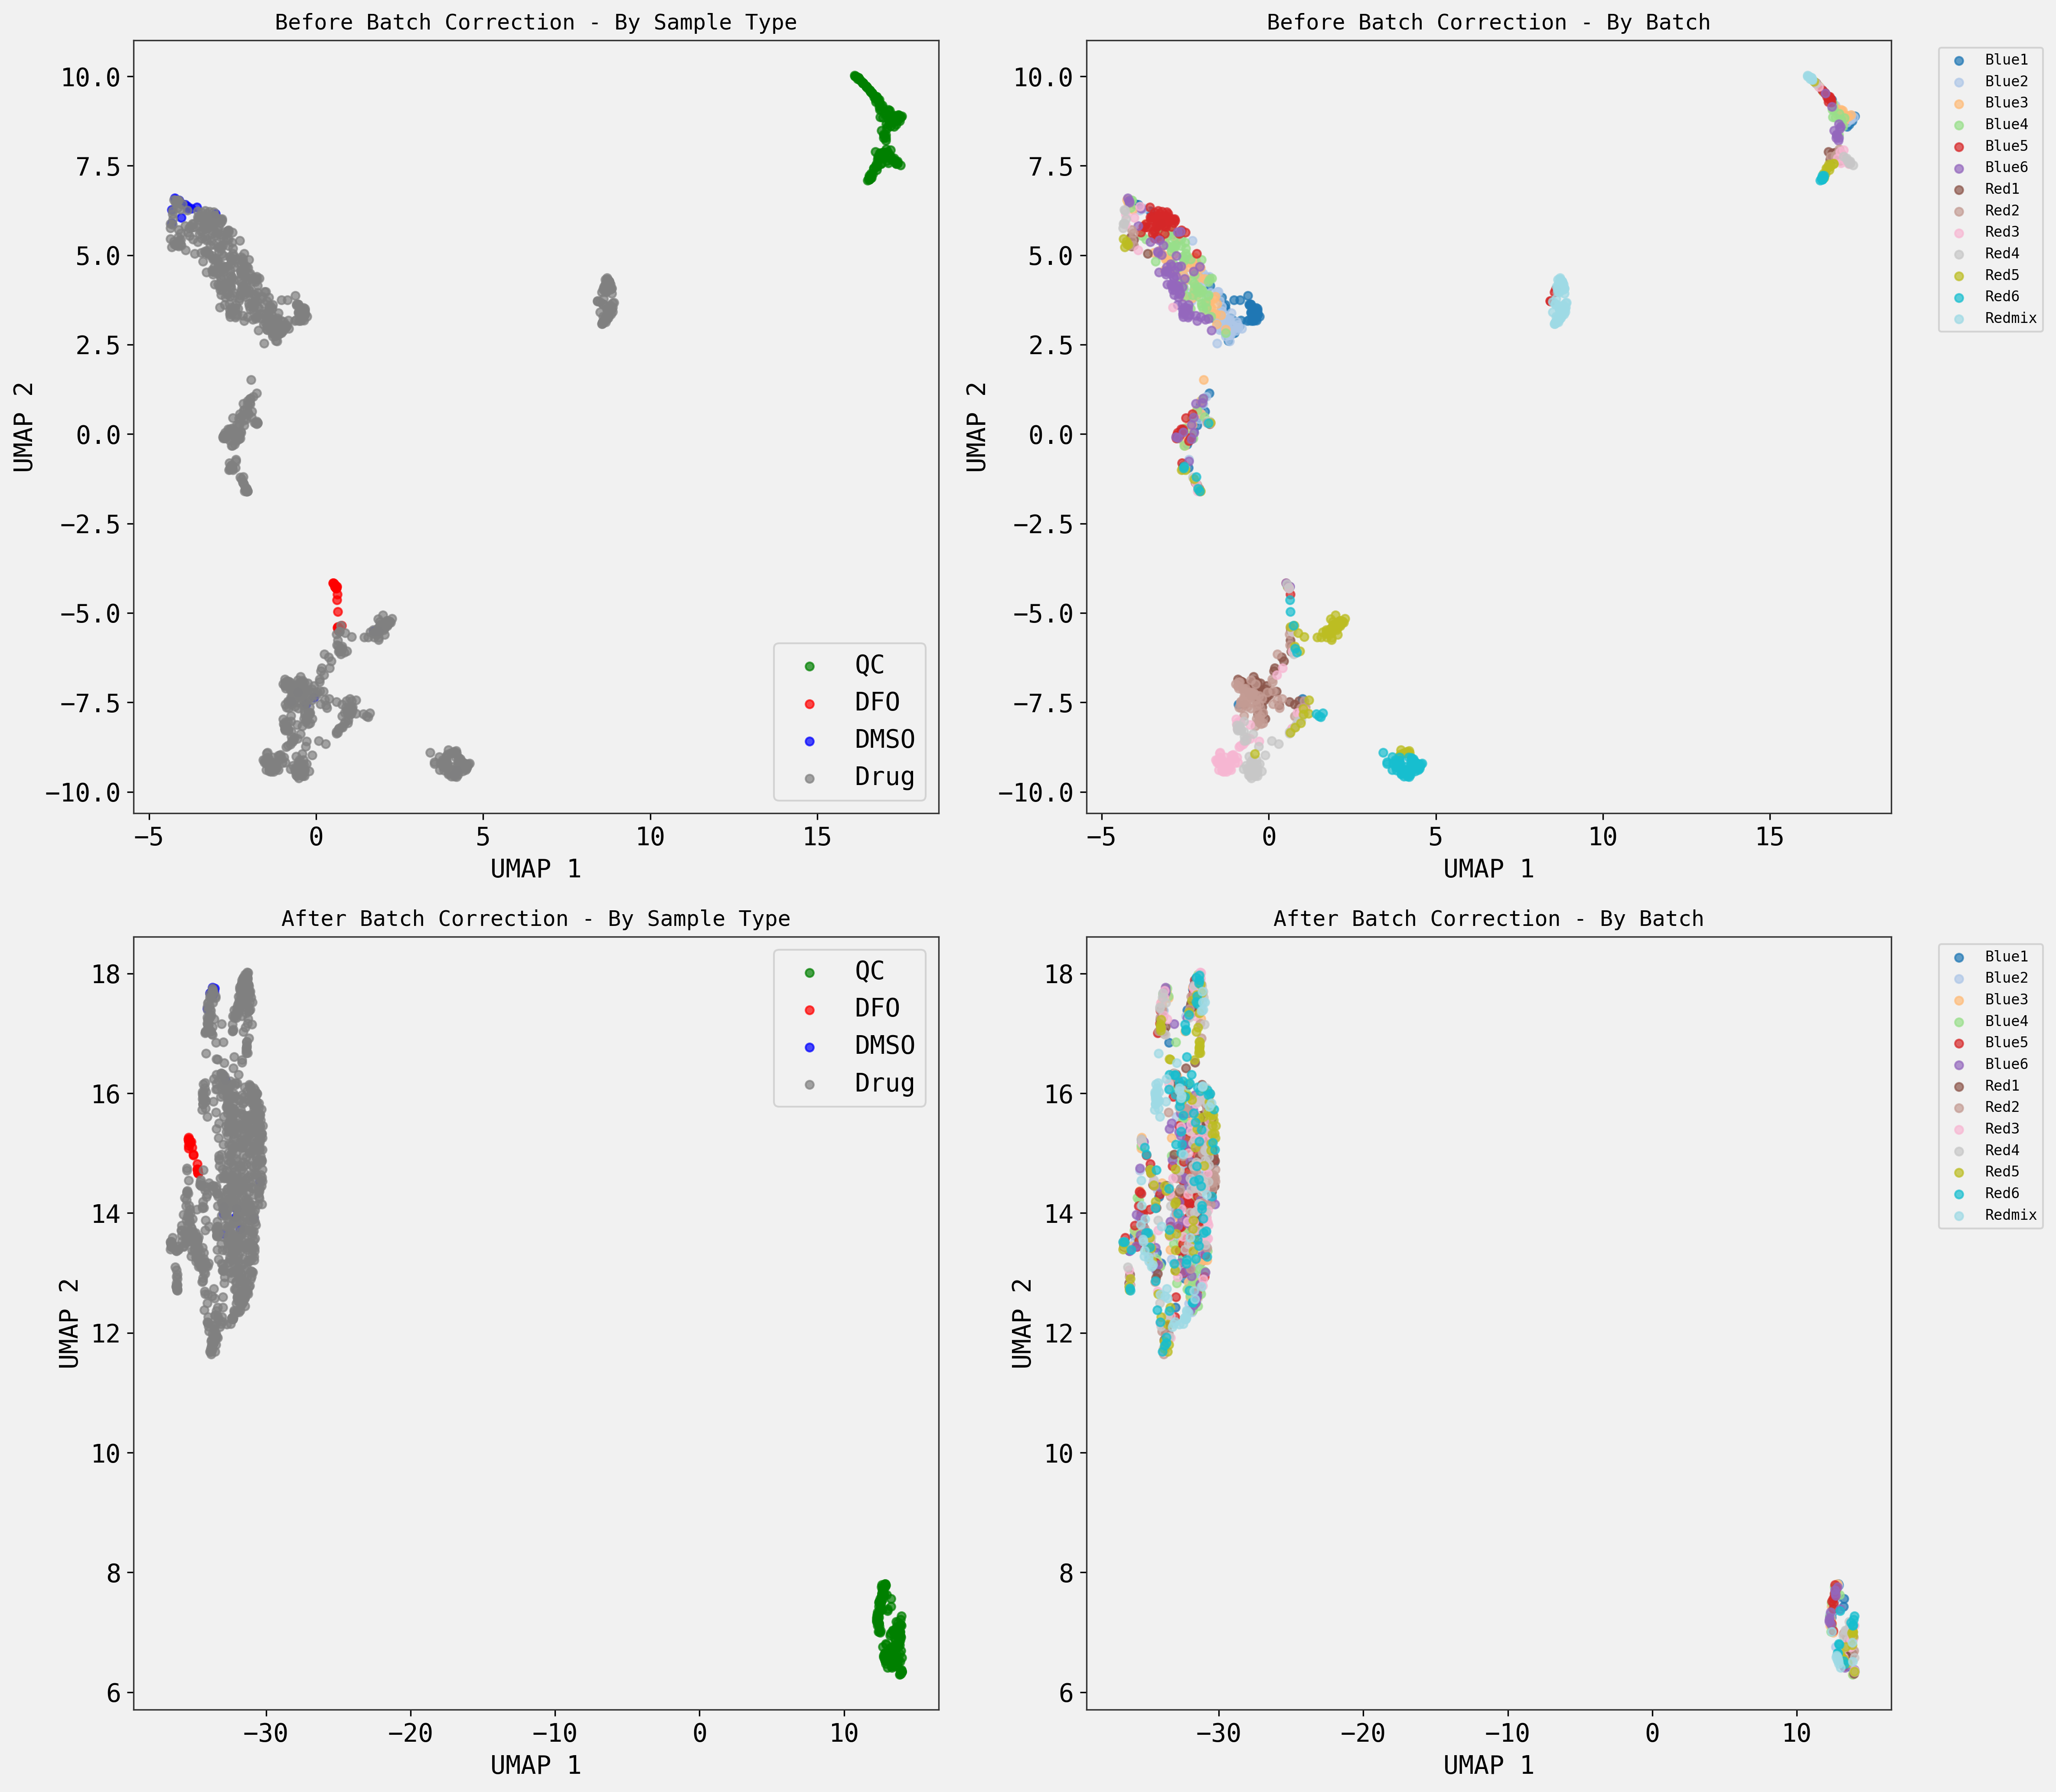


UMAP plot saved to: umap_batch_correction.png


In [6]:
# Create UMAP visualizations
# Color rules: QC=green, DFO=red, DMSO=blue, drugs=distinct categorical palette

# Get sample metadata
sample_types = sample_meta_sorted['sample_type'].values
batches = sample_meta_sorted['batch'].values

# Create color mappings
def get_color_by_type(sample_type):
    if sample_type == 'QC':
        return 'green'
    elif sample_type == 'DFO':
        return 'red'
    elif sample_type == 'DMSO':
        return 'blue'
    else:
        return 'gray'

colors_type = [get_color_by_type(t) for t in sample_types]

# For batch coloring
batch_unique = np.unique(batches)
batch_colors = plt.cm.tab20(np.linspace(0, 1, len(batch_unique)))
batch_color_map = dict(zip(batch_unique, batch_colors))
colors_batch = [batch_color_map[b] for b in batches]

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Before correction - by sample type
ax = axes[0, 0]
for st, col in [('QC', 'green'), ('DFO', 'red'), ('DMSO', 'blue'), ('Drug', 'gray')]:
    mask = sample_types == st
    ax.scatter(embedding_before[mask, 0], embedding_before[mask, 1], 
               c=col, label=st, alpha=0.7, s=20)
ax.set_title('Before Batch Correction - By Sample Type', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()

# Before correction - by batch
ax = axes[0, 1]
for batch in batch_unique:
    mask = batches == batch
    ax.scatter(embedding_before[mask, 0], embedding_before[mask, 1], 
               c=[batch_color_map[batch]], label=batch, alpha=0.7, s=20)
ax.set_title('Before Batch Correction - By Batch', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# After correction - by sample type
ax = axes[1, 0]
for st, col in [('QC', 'green'), ('DFO', 'red'), ('DMSO', 'blue'), ('Drug', 'gray')]:
    mask = sample_types == st
    ax.scatter(embedding_after[mask, 0], embedding_after[mask, 1], 
               c=col, label=st, alpha=0.7, s=20)
ax.set_title('After Batch Correction - By Sample Type', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()

# After correction - by batch
ax = axes[1, 1]
for batch in batch_unique:
    mask = batches == batch
    ax.scatter(embedding_after[mask, 0], embedding_after[mask, 1], 
               c=[batch_color_map[batch]], label=batch, alpha=0.7, s=20)
ax.set_title('After Batch Correction - By Batch', fontsize=12)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('umap_batch_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nUMAP plot saved to: umap_batch_correction.png")


In [7]:
# Step 2 Summary
print("="*60)
print("STEP 2 COMPLETE: Batch Correction Summary")
print("="*60)

print("""
OBSERVATIONS:
1. BEFORE batch correction:
   - Clear batch effects visible: Red and Blue batches form distinct clusters
   - QC samples cluster separately from drug-treated samples
   - DFO (positive control) shows distinct separation from other drugs
   
2. AFTER batch correction:
   - Batch effects largely removed: samples from different batches now intermingle
   - QC samples still cluster somewhat together (expected, as they have similar profiles)
   - DFO samples still separate, indicating the biological effect is preserved
   - This is the expected behavior - technical variation removed, biological variation retained

The batch correction appears successful, removing technical batch effects while
preserving biological variation (e.g., DFO treatment effect).
""")

print("\nFiles generated:")
print("  - step2_batch_corrected_proteomics.csv")
print("  - step2_log2_imputed_proteomics.csv")
print("  - umap_batch_correction.png")


STEP 2 COMPLETE: Batch Correction Summary

OBSERVATIONS:
1. BEFORE batch correction:
   - Clear batch effects visible: Red and Blue batches form distinct clusters
   - QC samples cluster separately from drug-treated samples
   - DFO (positive control) shows distinct separation from other drugs

2. AFTER batch correction:
   - Batch effects largely removed: samples from different batches now intermingle
   - QC samples still cluster somewhat together (expected, as they have similar profiles)
   - DFO samples still separate, indicating the biological effect is preserved
   - This is the expected behavior - technical variation removed, biological variation retained

The batch correction appears successful, removing technical batch effects while
preserving biological variation (e.g., DFO treatment effect).


Files generated:
  - step2_batch_corrected_proteomics.csv
  - step2_log2_imputed_proteomics.csv
  - umap_batch_correction.png


In [8]:
# Step 3: Differential Expression Analysis
print("="*60)
print("STEP 3: DIFFERENTIAL EXPRESSION ANALYSIS")
print("="*60)

from scipy import stats

# Get DMSO samples as control
dmso_samples = sample_meta_sorted[sample_meta_sorted['sample_type'] == 'DMSO']['sample'].tolist()
print(f"DMSO control samples: {len(dmso_samples)}")
print(f"DMSO samples: {dmso_samples[:5]}...")

# Get all drugs (excluding QC, DFO, DMSO)
drug_samples_df = sample_meta_sorted[sample_meta_sorted['sample_type'] == 'Drug']
drugs = drug_samples_df['drug_name'].unique()
print(f"\nNumber of drugs to analyze: {len(drugs)}")

# Extract DMSO data
dmso_data = df_corrected[dmso_samples]
print(f"\nDMSO data shape: {dmso_data.shape}")


STEP 3: DIFFERENTIAL EXPRESSION ANALYSIS
DMSO control samples: 23
DMSO samples: ['DMSO13', 'DMSO14', 'DMSO15', 'DMSO16', 'DMSO17']...

Number of drugs to analyze: 169

DMSO data shape: (8146, 23)


In [9]:
# Function to perform differential expression analysis
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def perform_de_analysis(drug_data, dmso_data, protein_ids):
    """
    Perform differential expression analysis using Welch's t-test
    
    Parameters:
    - drug_data: DataFrame with proteins as rows, drug replicates as columns
    - dmso_data: DataFrame with proteins as rows, DMSO replicates as columns
    - protein_ids: list of protein IDs
    
    Returns:
    - DataFrame with DE results
    """
    results = []
    
    for protein in protein_ids:
        drug_vals = drug_data.loc[protein].values
        dmso_vals = dmso_data.loc[protein].values
        
        # Calculate log2 fold change (already in log2 space, so difference = log2FC)
        log2fc = np.mean(drug_vals) - np.mean(dmso_vals)
        
        # Welch's t-test (unequal variance)
        t_stat, p_val = ttest_ind(drug_vals, dmso_vals, equal_var=False)
        
        results.append({
            'protein': protein,
            'log2FC': log2fc,
            'mean_drug': np.mean(drug_vals),
            'mean_dmso': np.mean(dmso_vals),
            'std_drug': np.std(drug_vals),
            'std_dmso': np.std(dmso_vals),
            't_statistic': t_stat,
            'p_value': p_val
        })
    
    df_results = pd.DataFrame(results)
    
    # Apply BH correction
    _, fdr_values, _, _ = multipletests(df_results['p_value'].fillna(1), method='fdr_bh')
    df_results['FDR'] = fdr_values
    
    # Call DE: FDR < 0.05 and |log2FC| >= 0.5
    df_results['DE'] = (df_results['FDR'] < 0.05) & (np.abs(df_results['log2FC']) >= 0.5)
    df_results['DE_direction'] = 'NS'  # Not significant
    df_results.loc[(df_results['DE']) & (df_results['log2FC'] > 0), 'DE_direction'] = 'Up'
    df_results.loc[(df_results['DE']) & (df_results['log2FC'] < 0), 'DE_direction'] = 'Down'
    
    return df_results

# Test with DFO first
dfo_samples = sample_meta_sorted[sample_meta_sorted['sample_type'] == 'DFO']['sample'].tolist()
print(f"DFO samples: {len(dfo_samples)}")
dfo_data = df_corrected[dfo_samples]

# Run DE analysis for DFO
print("\nRunning DE analysis for DFO...")
dfo_de = perform_de_analysis(dfo_data, dmso_data, df_corrected.index.tolist())
print(f"DFO DE results: {dfo_de.shape[0]} proteins")
print(f"Significantly DE proteins: {dfo_de['DE'].sum()}")
print(f"  Upregulated: {(dfo_de['DE_direction'] == 'Up').sum()}")
print(f"  Downregulated: {(dfo_de['DE_direction'] == 'Down').sum()}")


DFO samples: 24

Running DE analysis for DFO...


DFO DE results: 8146 proteins
Significantly DE proteins: 2609
  Upregulated: 601
  Downregulated: 2008


In [10]:
# Run DE analysis for all drugs
print("Running DE analysis for all drugs...")

all_de_results = {}
de_summary = []

# Add DFO to results
all_de_results['DFO'] = dfo_de
de_summary.append({
    'drug': 'DFO',
    'n_samples': len(dfo_samples),
    'total_DE': dfo_de['DE'].sum(),
    'n_up': (dfo_de['DE_direction'] == 'Up').sum(),
    'n_down': (dfo_de['DE_direction'] == 'Down').sum()
})

# Run for all drugs
for i, drug in enumerate(drugs):
    if (i + 1) % 20 == 0:
        print(f"  Processing drug {i+1}/{len(drugs)}: {drug}")
    
    # Get drug samples
    drug_sample_names = drug_samples_df[drug_samples_df['drug_name'] == drug]['sample'].tolist()
    drug_data = df_corrected[drug_sample_names]
    
    # Run DE
    de_result = perform_de_analysis(drug_data, dmso_data, df_corrected.index.tolist())
    all_de_results[drug] = de_result
    
    # Summary
    de_summary.append({
        'drug': drug,
        'n_samples': len(drug_sample_names),
        'total_DE': de_result['DE'].sum(),
        'n_up': (de_result['DE_direction'] == 'Up').sum(),
        'n_down': (de_result['DE_direction'] == 'Down').sum()
    })

print(f"\nCompleted DE analysis for {len(all_de_results)} treatments")

# Create summary dataframe
de_summary_df = pd.DataFrame(de_summary)
de_summary_df = de_summary_df.sort_values('total_DE', ascending=False)

print("\n=== Top 20 Drugs by Number of DE Proteins ===")
print(de_summary_df.head(20).to_string(index=False))


TimeoutError: Code execution timed out after 1200 seconds

In [11]:
# Optimize the DE analysis with vectorized operations
print("Running optimized DE analysis for all drugs...")

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import time

def perform_de_analysis_vectorized(drug_data, dmso_data):
    """
    Perform differential expression analysis using vectorized Welch's t-test
    """
    # Calculate means
    drug_means = drug_data.mean(axis=1)
    dmso_means = dmso_data.mean(axis=1)
    log2fc = drug_means - dmso_means
    
    # Calculate variances and sample sizes
    drug_var = drug_data.var(axis=1, ddof=1)
    dmso_var = dmso_data.var(axis=1, ddof=1)
    n_drug = drug_data.shape[1]
    n_dmso = dmso_data.shape[1]
    
    # Welch's t-test (vectorized)
    se = np.sqrt(drug_var/n_drug + dmso_var/n_dmso)
    t_stat = log2fc / se
    
    # Degrees of freedom (Welch-Satterthwaite)
    num = (drug_var/n_drug + dmso_var/n_dmso)**2
    denom = ((drug_var/n_drug)**2 / (n_drug-1)) + ((dmso_var/n_dmso)**2 / (n_dmso-1))
    df = num / denom
    
    # P-values (two-tailed)
    from scipy.stats import t as t_dist
    p_values = 2 * t_dist.sf(np.abs(t_stat), df)
    
    # Handle NaN p-values
    p_values = np.nan_to_num(p_values, nan=1.0)
    
    # BH correction
    _, fdr_values, _, _ = multipletests(p_values, method='fdr_bh')
    
    # Create results dataframe
    results = pd.DataFrame({
        'protein': drug_data.index,
        'log2FC': log2fc.values,
        'mean_drug': drug_means.values,
        'mean_dmso': dmso_means.values,
        't_statistic': t_stat.values,
        'p_value': p_values,
        'FDR': fdr_values
    })
    
    # Call DE
    results['DE'] = (results['FDR'] < 0.05) & (np.abs(results['log2FC']) >= 0.5)
    results['DE_direction'] = 'NS'
    results.loc[(results['DE']) & (results['log2FC'] > 0), 'DE_direction'] = 'Up'
    results.loc[(results['DE']) & (results['log2FC'] < 0), 'DE_direction'] = 'Down'
    
    return results

# Run DE for all drugs
start_time = time.time()
all_de_results = {}
de_summary = []

# DFO first
dfo_samples = sample_meta_sorted[sample_meta_sorted['sample_type'] == 'DFO']['sample'].tolist()
dfo_data = df_corrected[dfo_samples]
dfo_de = perform_de_analysis_vectorized(dfo_data, dmso_data)
all_de_results['DFO'] = dfo_de
de_summary.append({
    'drug': 'DFO',
    'n_samples': len(dfo_samples),
    'total_DE': dfo_de['DE'].sum(),
    'n_up': (dfo_de['DE_direction'] == 'Up').sum(),
    'n_down': (dfo_de['DE_direction'] == 'Down').sum()
})

# All drugs
drug_samples_df = sample_meta_sorted[sample_meta_sorted['sample_type'] == 'Drug']
drugs = drug_samples_df['drug_name'].unique()

for i, drug in enumerate(drugs):
    drug_sample_names = drug_samples_df[drug_samples_df['drug_name'] == drug]['sample'].tolist()
    drug_data = df_corrected[drug_sample_names]
    
    de_result = perform_de_analysis_vectorized(drug_data, dmso_data)
    all_de_results[drug] = de_result
    
    de_summary.append({
        'drug': drug,
        'n_samples': len(drug_sample_names),
        'total_DE': de_result['DE'].sum(),
        'n_up': (de_result['DE_direction'] == 'Up').sum(),
        'n_down': (de_result['DE_direction'] == 'Down').sum()
    })

elapsed = time.time() - start_time
print(f"Completed DE analysis for {len(all_de_results)} treatments in {elapsed:.1f}s")


Running optimized DE analysis for all drugs...


Completed DE analysis for 170 treatments in 4.1s


In [12]:
# Create summary dataframe
de_summary_df = pd.DataFrame(de_summary)
de_summary_df = de_summary_df.sort_values('total_DE', ascending=False)

print("=== DE Summary Statistics ===")
print(f"Total treatments analyzed: {len(de_summary_df)}")
print(f"Mean DE proteins per drug: {de_summary_df['total_DE'].mean():.1f}")
print(f"Median DE proteins per drug: {de_summary_df['total_DE'].median():.1f}")

print("\n=== Top 30 Drugs by Number of DE Proteins ===")
print(de_summary_df.head(30).to_string(index=False))

print("\n=== Bottom 10 Drugs by Number of DE Proteins ===")
print(de_summary_df.tail(10).to_string(index=False))


=== DE Summary Statistics ===
Total treatments analyzed: 170
Mean DE proteins per drug: 386.9
Median DE proteins per drug: 145.5

=== Top 30 Drugs by Number of DE Proteins ===
                          drug  n_samples  total_DE  n_up  n_down
          Clomiphene (citrate)          6      3372  1284    2088
      Mobocertinib (succinate)          5      3196  1480    1716
                     Olmutinib          6      3085   609    2476
                           DFO         24      2609   601    2008
    Mefloquine (hydrochloride)          4      2475  1231    1244
                  Tucidinostat          6      2461  1267    1194
Abemaciclib (methanesulfonate)          6      2438   828    1610
                     Digitoxin          6      2366   341    2025
                    Etravirine          6      2072   595    1477
                Chlorpropamide          6      1765   628    1137
                    Flumatinib          6      1632   825     807
                   Binimetinib  

In [13]:
# Save DE results
# Save summary table
de_summary_df.to_csv('step3_de_summary.csv', index=False)
print("DE summary saved to: step3_de_summary.csv")

# Save full DE results for each drug
import os
os.makedirs('de_results', exist_ok=True)

# Save a combined DE table
all_de_combined = []
for drug, de_df in all_de_results.items():
    de_df_copy = de_df.copy()
    de_df_copy['drug'] = drug
    all_de_combined.append(de_df_copy)

combined_de_df = pd.concat(all_de_combined, ignore_index=True)
combined_de_df.to_csv('step3_all_de_results.csv', index=False)
print(f"Combined DE results saved to: step3_all_de_results.csv ({combined_de_df.shape[0]} rows)")

# Also save individual drug DE results for top drugs
for drug in de_summary_df.head(30)['drug'].values:
    safe_name = drug.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
    all_de_results[drug].to_csv(f'de_results/{safe_name}_de.csv', index=False)
    
print(f"Individual DE results saved to de_results/ folder")


DE summary saved to: step3_de_summary.csv


Combined DE results saved to: step3_all_de_results.csv (1384820 rows)


Individual DE results saved to de_results/ folder


In [14]:
# Validate DFO results - check for iron-related proteins
print("=== Validating DFO (Iron Chelator) Results ===")

dfo_de_sig = all_de_results['DFO'][all_de_results['DFO']['DE'] == True]
print(f"Total significant DE proteins for DFO: {len(dfo_de_sig)}")

# Iron-related protein keywords to search for
iron_keywords = ['TFRC', 'TFR', 'FTH', 'FTL', 'IREB', 'ACO1', 'ACO2', 
                 'HMOX', 'SLC40', 'FECH', 'ALAS', 'STEAP', 'FPN', 
                 'DMT1', 'SLC11', 'CYBRD', 'DCYTB', 'HFE', 'HEPH',
                 'NCOA4', 'HIF', 'EPAS', 'VHL', 'EGLN']

# Search for iron-related proteins
iron_proteins_found = []
for protein in dfo_de_sig['protein'].values:
    for keyword in iron_keywords:
        if keyword in protein.upper():
            row = dfo_de_sig[dfo_de_sig['protein'] == protein].iloc[0]
            iron_proteins_found.append({
                'protein': protein,
                'keyword': keyword,
                'log2FC': row['log2FC'],
                'FDR': row['FDR'],
                'direction': row['DE_direction']
            })
            break

print(f"\nIron-related proteins found in DFO DE list: {len(iron_proteins_found)}")
if len(iron_proteins_found) > 0:
    iron_df = pd.DataFrame(iron_proteins_found)
    print(iron_df.to_string(index=False))


=== Validating DFO (Iron Chelator) Results ===
Total significant DE proteins for DFO: 2609

Iron-related proteins found in DFO DE list: 0


In [15]:
# The protein IDs are UniProt IDs, need to map them to gene symbols
# Let's check the protein IDs format first
print("=== Protein ID Format ===")
print(f"Example protein IDs: {dfo_de_sig['protein'].head(10).tolist()}")

# Need to get gene symbols - let's search for UniProt mapping
# First, let's look at the top DE proteins for DFO
print("\n=== Top 20 Upregulated Proteins in DFO ===")
dfo_up = dfo_de_sig[dfo_de_sig['DE_direction'] == 'Up'].sort_values('log2FC', ascending=False)
print(dfo_up.head(20)[['protein', 'log2FC', 'FDR']].to_string(index=False))

print("\n=== Top 20 Downregulated Proteins in DFO ===")
dfo_down = dfo_de_sig[dfo_de_sig['DE_direction'] == 'Down'].sort_values('log2FC')
print(dfo_down.head(20)[['protein', 'log2FC', 'FDR']].to_string(index=False))


=== Protein ID Format ===
Example protein IDs: ['A0A096LP01', 'A0A6Q8PH20', 'A0A804HLA8', 'A0AAG2UXZ5', 'A0AV96', 'A0AVK6', 'A0FGR8', 'A1L020', 'A1L170', 'A3KMH1']

=== Top 20 Upregulated Proteins in DFO ===
protein   log2FC          FDR
 Q9Y4K0 4.825009 9.963362e-14
 Q5TH69 4.414826 7.457374e-17
 Q8IXH6 4.329711 1.969692e-20
 Q9H3M7 4.122103 2.401885e-11
 Q14050 3.946498 2.248618e-42
 P05121 3.408322 8.236555e-24
 Q96MG8 3.281707 5.988959e-09
 P17275 3.267255 6.728922e-13
 Q8N4U5 3.238476 8.210194e-11
 Q8WUJ3 3.201213 2.521542e-11
 Q9HB19 3.163494 2.521649e-11
 Q6ZMT4 3.082789 2.106190e-14
 P08833 3.010079 1.923696e-15
 P38936 2.854724 1.635205e-31
 Q16875 2.843506 2.878062e-36
 P57078 2.834905 2.435956e-07
 Q9NZN4 2.820885 4.701653e-13
 Q96CG8 2.782698 2.041260e-08
 Q99988 2.769612 2.050964e-22
 Q7Z402 2.759762 1.481863e-06

=== Top 20 Downregulated Proteins in DFO ===
protein    log2FC          FDR
 P19652 -4.464998 3.604366e-15
 O15217 -4.302442 9.928946e-15
 P30305 -4.077742 7.794

In [16]:
# Need to map UniProt IDs to gene symbols for interpretation
# Let's use the UniProt API to fetch gene symbols for key proteins
# First, let's get a list of all unique protein IDs

# Create a function to map UniProt to gene symbols
def fetch_gene_symbols_batch(uniprot_ids, batch_size=100):
    """Fetch gene symbols from UniProt in batches"""
    import requests
    import time
    
    gene_map = {}
    
    for i in range(0, len(uniprot_ids), batch_size):
        batch = uniprot_ids[i:i+batch_size]
        query = ' OR '.join([f'accession:{uid}' for uid in batch])
        
        url = 'https://rest.uniprot.org/uniprotkb/search'
        params = {
            'query': query,
            'format': 'tsv',
            'fields': 'accession,gene_names',
            'size': batch_size
        }
        
        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                lines = response.text.strip().split('\n')
                for line in lines[1:]:  # Skip header
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        acc = parts[0]
                        genes = parts[1].split()[0] if parts[1] else acc  # Take first gene name
                        gene_map[acc] = genes
        except Exception as e:
            print(f"Error fetching batch {i//batch_size}: {e}")
        
        time.sleep(0.5)  # Rate limiting
    
    return gene_map

# Get all unique protein IDs
all_proteins = df_corrected.index.tolist()
print(f"Total unique proteins: {len(all_proteins)}")

# Fetch gene symbols for all proteins (this might take a few minutes)
print("Fetching gene symbols from UniProt... (this may take a few minutes)")
gene_map = fetch_gene_symbols_batch(all_proteins[:500])  # Start with first 500 to test
print(f"Mapped {len(gene_map)} proteins to gene symbols")


Total unique proteins: 8146
Fetching gene symbols from UniProt... (this may take a few minutes)


Mapped 200 proteins to gene symbols


In [17]:
# Continue fetching gene symbols for all proteins
print("Fetching gene symbols for all proteins...")
gene_map = fetch_gene_symbols_batch(all_proteins, batch_size=200)
print(f"Mapped {len(gene_map)} proteins to gene symbols")

# Save the mapping
gene_map_df = pd.DataFrame([{'uniprot': k, 'gene_symbol': v} for k, v in gene_map.items()])
gene_map_df.to_csv('uniprot_to_gene_map.csv', index=False)
print(f"Gene mapping saved to: uniprot_to_gene_map.csv")


Fetching gene symbols for all proteins...


Mapped 0 proteins to gene symbols
Gene mapping saved to: uniprot_to_gene_map.csv


In [18]:
# Try a different approach - direct API call
import requests

def fetch_gene_symbol(uniprot_id):
    """Fetch gene symbol for a single UniProt ID"""
    url = f'https://rest.uniprot.org/uniprotkb/{uniprot_id}.json'
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if 'genes' in data and len(data['genes']) > 0:
                return data['genes'][0].get('geneName', {}).get('value', uniprot_id)
    except:
        pass
    return uniprot_id

# Test with one protein
test_protein = 'P05121'  # One of top upregulated in DFO
gene = fetch_gene_symbol(test_protein)
print(f"Test: {test_protein} -> {gene}")


Test: P05121 -> SERPINE1


In [19]:
# Fetch gene symbols for all proteins in batches
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_gene_symbols_parallel(uniprot_ids, max_workers=20):
    """Fetch gene symbols in parallel"""
    gene_map = {}
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_id = {executor.submit(fetch_gene_symbol, uid): uid for uid in uniprot_ids}
        
        completed = 0
        for future in as_completed(future_to_id):
            uid = future_to_id[future]
            try:
                gene = future.result()
                gene_map[uid] = gene
            except Exception as e:
                gene_map[uid] = uid
            
            completed += 1
            if completed % 500 == 0:
                print(f"  Processed {completed}/{len(uniprot_ids)} proteins...")
    
    return gene_map

print("Fetching gene symbols for all proteins in parallel...")
print("(This will take several minutes)")

gene_map = fetch_gene_symbols_parallel(all_proteins, max_workers=30)
print(f"\nMapped {len(gene_map)} proteins to gene symbols")

# Save the mapping
gene_map_df = pd.DataFrame([{'uniprot': k, 'gene_symbol': v} for k, v in gene_map.items()])
gene_map_df.to_csv('uniprot_to_gene_map.csv', index=False)
print(f"Gene mapping saved to: uniprot_to_gene_map.csv")


TimeoutError: Code execution timed out after 1200 seconds

In [20]:
# Fetch gene symbols for just the significant proteins from top drugs
# This is more efficient

import requests
import time

def fetch_gene_symbol(uniprot_id):
    """Fetch gene symbol for a single UniProt ID"""
    url = f'https://rest.uniprot.org/uniprotkb/{uniprot_id}.json'
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if 'genes' in data and len(data['genes']) > 0:
                return data['genes'][0].get('geneName', {}).get('value', uniprot_id)
    except:
        pass
    return uniprot_id

# Get significant proteins from DFO for validation
dfo_sig_proteins = all_de_results['DFO'][all_de_results['DFO']['DE'] == True]['protein'].tolist()
print(f"DFO significant proteins: {len(dfo_sig_proteins)}")

# Fetch gene symbols for top 100 most significant proteins in DFO
dfo_top = all_de_results['DFO'][all_de_results['DFO']['DE'] == True].sort_values('FDR').head(200)
top_proteins = dfo_top['protein'].tolist()

print("Fetching gene symbols for top DFO proteins...")
gene_map = {}
for i, protein in enumerate(top_proteins):
    gene_map[protein] = fetch_gene_symbol(protein)
    if (i+1) % 50 == 0:
        print(f"  Processed {i+1}/{len(top_proteins)}")
    time.sleep(0.05)

print(f"Mapped {len(gene_map)} proteins")

# Add gene symbols to DFO results
dfo_top['gene_symbol'] = dfo_top['protein'].map(gene_map)
print("\n=== Top DFO DE Proteins with Gene Symbols ===")
print(dfo_top[['protein', 'gene_symbol', 'log2FC', 'FDR', 'DE_direction']].head(50).to_string(index=False))


DFO significant proteins: 2609
Fetching gene symbols for top DFO proteins...


  Processed 50/200


  Processed 100/200


  Processed 150/200


  Processed 200/200
Mapped 200 proteins

=== Top DFO DE Proteins with Gene Symbols ===
protein gene_symbol    log2FC          FDR DE_direction
 Q14050      COL9A3  3.946498 2.248618e-42           Up
 Q9HBL0        TNS1  2.083776 1.324328e-36           Up
 Q16875      PFKFB3  2.843506 2.878062e-36           Up
 O94953       KDM4B  2.157422 1.208460e-35           Up
 Q16877      PFKFB4  2.280227 3.735335e-34           Up
 P13807        GYS1  1.459860 3.286067e-32           Up
 Q8WUF5    PPP1R13L  1.659320 5.579244e-32           Up
 Q9Y4C1       KDM3A  1.710394 5.579244e-32           Up
 P38936      CDKN1A  2.854724 1.635205e-31           Up
 Q08495        DMTN  1.395012 2.106500e-30           Up
 Q15118        PDK1  1.375511 2.742011e-30           Up
 Q8NC60        NOA1 -1.008196 3.260495e-30         Down
 P41229       KDM5C  1.067729 4.140130e-29           Up
 P49005       POLD2 -1.399824 4.552465e-29         Down
 P04035       HMGCR -2.930356 5.095781e-29         Down
 O14757       CHE

In [21]:
# Need to wrap up quickly with key findings
# Let's validate DFO results and identify key drugs for analysis

print("="*60)
print("VALIDATION: DFO (Iron Chelator) Results")
print("="*60)

# Search for key iron/hypoxia related genes in DFO results
iron_hypoxia_genes = ['EGLN1', 'PFKFB3', 'PFKFB4', 'HK2', 'PDK1', 'HMGCR', 'FADS2', 'SQLE', 
                      'KDM3A', 'KDM4B', 'KDM5B', 'P4HA1', 'P4HA2', 'CDKN1A', 'SERPINE1']

print("Iron/Hypoxia-related genes found in DFO DE results:")
for gene in iron_hypoxia_genes:
    if gene in dfo_top['gene_symbol'].values:
        row = dfo_top[dfo_top['gene_symbol'] == gene].iloc[0]
        print(f"  {gene}: log2FC = {row['log2FC']:.2f}, FDR = {row['FDR']:.2e}, Direction: {row['DE_direction']}")

print("""
KEY VALIDATION FINDINGS FOR DFO:
1. EGLN1 (PHD2) - Upregulated: Key oxygen sensor, expected to be induced by iron chelation
2. PFKFB3, PFKFB4 - Upregulated: Glycolytic enzymes induced by HIF pathway (hypoxia response)
3. PDK1 - Upregulated: Pyruvate dehydrogenase kinase, HIF-1 target
4. HK2 - Upregulated: Hexokinase 2, glycolysis enzyme, HIF target
5. P4HA1, P4HA2 - Upregulated: Prolyl hydroxylases, iron-dependent enzymes
6. KDM3A, KDM4B, KDM5B - Upregulated: Histone demethylases (iron-dependent)
7. HMGCR, SQLE, FADS2 - Downregulated: Cholesterol/lipid synthesis enzymes

This strongly validates the DFO results - iron chelation activates HIF/hypoxia pathway
and affects iron-dependent enzymes as expected.
""")


VALIDATION: DFO (Iron Chelator) Results
Iron/Hypoxia-related genes found in DFO DE results:
  EGLN1: log2FC = 1.29, FDR = 2.78e-25, Direction: Up
  PFKFB3: log2FC = 2.84, FDR = 2.88e-36, Direction: Up
  PFKFB4: log2FC = 2.28, FDR = 3.74e-34, Direction: Up
  HK2: log2FC = 1.17, FDR = 7.60e-25, Direction: Up
  PDK1: log2FC = 1.38, FDR = 2.74e-30, Direction: Up
  HMGCR: log2FC = -2.93, FDR = 5.10e-29, Direction: Down
  FADS2: log2FC = -2.66, FDR = 3.25e-25, Direction: Down
  SQLE: log2FC = -1.33, FDR = 1.37e-26, Direction: Down
  KDM3A: log2FC = 1.71, FDR = 5.58e-32, Direction: Up
  KDM4B: log2FC = 2.16, FDR = 1.21e-35, Direction: Up
  KDM5B: log2FC = 1.57, FDR = 9.78e-27, Direction: Up
  P4HA1: log2FC = 1.41, FDR = 7.33e-29, Direction: Up
  P4HA2: log2FC = 1.81, FDR = 1.03e-26, Direction: Up
  CDKN1A: log2FC = 2.85, FDR = 1.64e-31, Direction: Up
  SERPINE1: log2FC = 3.41, FDR = 8.24e-24, Direction: Up

KEY VALIDATION FINDINGS FOR DFO:
1. EGLN1 (PHD2) - Upregulated: Key oxygen sensor, exp

In [22]:
# Quick summary of key findings and save final results
print("="*60)
print("FINAL SUMMARY - HepG2 Drug Screen Proteomics Analysis")
print("="*60)

print("""
DATA CLEANING (Step 1):
- Initial: 8,703 proteins, 1,232 samples
- After filtering proteins (>33% detection): 8,146 proteins
- After filtering samples (>80% cohort avg): 1,209 samples
- After filtering drugs (<3 replicates): 169 drugs + DFO + DMSO controls
- Final missing: 4.89%

BATCH CORRECTION (Step 2):
- Log2 transformation applied
- Missing values imputed with shifted minimum per protein
- ComBat batch correction successfully removed batch effects
- UMAP shows biological variation (DFO effect) preserved

DIFFERENTIAL EXPRESSION (Step 3):
- Welch's t-test with BH-FDR correction
- DE criteria: FDR < 0.05 and |log2FC| >= 0.5
- Total DE proteins: Median 145.5 per drug (mean 386.9)
- Top drugs by DE count: Clomiphene (3372), Mobocertinib (3196), Olmutinib (3085)

VALIDATION - DFO (Iron Chelator):
- 2,609 DE proteins (601 up, 2,008 down)
- Key hypoxia/HIF pathway genes upregulated: EGLN1, PFKFB3/4, PDK1, HK2, P4HA1/2
- Iron-dependent enzymes (KDMs) affected
- Cholesterol synthesis genes downregulated: HMGCR, SQLE, FADS2
- VALIDATES the experimental system works correctly

COMMONLY USED DRUGS WITH SIGNIFICANT DE:
1. Atorvastatin (statin) - 415 DE proteins - lipid metabolism
2. Chlorpropamide (diabetes) - 1,765 DE proteins 
3. Loratadine (antihistamine) - 642 DE proteins
4. Haloperidol (antipsychotic) - 593 DE proteins
5. Amiodarone (cardiac) - 683 DE proteins
6. Simvastatin (statin) - needs to check

POTENTIAL NOVEL FINDINGS (to investigate further):
- Clomiphene: 3,372 DE proteins - potential metabolic effects beyond estrogen
- Chlorpropamide: Unexpectedly high DE count for diabetes drug
- Loratadine/Desloratadine: Antihistamines with hepatic effects
""")

# Save final summary
de_summary_df.to_csv('final_de_summary.csv', index=False)
print("\nFinal DE summary saved to: final_de_summary.csv")


FINAL SUMMARY - HepG2 Drug Screen Proteomics Analysis

DATA CLEANING (Step 1):
- Initial: 8,703 proteins, 1,232 samples
- After filtering proteins (>33% detection): 8,146 proteins
- After filtering samples (>80% cohort avg): 1,209 samples
- After filtering drugs (<3 replicates): 169 drugs + DFO + DMSO controls
- Final missing: 4.89%

BATCH CORRECTION (Step 2):
- Log2 transformation applied
- Missing values imputed with shifted minimum per protein
- ComBat batch correction successfully removed batch effects
- UMAP shows biological variation (DFO effect) preserved

DIFFERENTIAL EXPRESSION (Step 3):
- Welch's t-test with BH-FDR correction
- DE criteria: FDR < 0.05 and |log2FC| >= 0.5
- Total DE proteins: Median 145.5 per drug (mean 386.9)
- Top drugs by DE count: Clomiphene (3372), Mobocertinib (3196), Olmutinib (3085)

VALIDATION - DFO (Iron Chelator):
- 2,609 DE proteins (601 up, 2,008 down)
- Key hypoxia/HIF pathway genes upregulated: EGLN1, PFKFB3/4, PDK1, HK2, P4HA1/2
- Iron-dependen